In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import plot_tree
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/dalark/.local/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/dalark/.local/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/dalark/.local/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/dalark/.local/

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
dataset_el_pino = pd.read_csv("../data/dataModelCSV/label_encoding.csv", sep=";")
dataset_el_pino.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,24,41,373,638,38,462,391,26,6,242,...,112,19,40,40,41,39,13,40,1,135
1,1364,508,1016,889,796,833,693,297,260,244,...,57,42,53,40,39,73,39,53,1,14
2,575,1177,1051,452,975,330,649,23,31,9,...,112,54,44,99,22,26,26,65,1,14
3,622,670,711,120,169,149,321,411,251,411,...,18,1,3,90,90,82,86,61,1,15
4,1342,1571,1102,964,923,362,297,574,491,349,...,46,53,51,72,88,73,9,30,1,15


In [3]:
rows, columns = dataset_el_pino.shape
rows

14278

In [4]:
delete_rows = [["GRD"], # Modelo 1 y 2
              ["GRD", "Edad en años", "Sexo (Desc)"], # Modelo 3 y 4
               ['Diag 03 Secundario (cod+des)',
 'Diag 04 Secundario (cod+des)',
 'Diag 05 Secundario (cod+des)',
 'Diag 06 Secundario (cod+des)',
 'Diag 07 Secundario (cod+des)',
 'Diag 08 Secundario (cod+des)',
 'Diag 09 Secundario (cod+des)',
 'Diag 10 Secundario (cod+des)',
 'Diag 11 Secundario (cod+des)',
 'Diag 12 Secundario (cod+des)',
 'Diag 13 Secundario (cod+des)',
 'Diag 14 Secundario (cod+des)',
 'Diag 15 Secundario (cod+des)',
 'Diag 16 Secundario (cod+des)',
 'Diag 17 Secundario (cod+des)',
 'Diag 18 Secundario (cod+des)',
 'Diag 19 Secundario (cod+des)',
 'Diag 20 Secundario (cod+des)',
 'Diag 21 Secundario (cod+des)',
 'Diag 22 Secundario (cod+des)',
 'Diag 23 Secundario (cod+des)',
 'Diag 24 Secundario (cod+des)',
 'Diag 25 Secundario (cod+des)',
 'Diag 26 Secundario (cod+des)',
 'Diag 27 Secundario (cod+des)',
 'Diag 28 Secundario (cod+des)',
 'Diag 29 Secundario (cod+des)',
 'Diag 30 Secundario (cod+des)',
 'Diag 31 Secundario (cod+des)',
 'Diag 32 Secundario (cod+des)',
 'Diag 33 Secundario (cod+des)',
 'Diag 34 Secundario (cod+des)',
 'Diag 35 Secundario (cod+des)','Proced 06 Secundario (cod+des)',
 'Proced 07 Secundario (cod+des)',
 'Proced 08 Secundario (cod+des)',
 'Proced 09 Secundario (cod+des)',
 'Proced 10 Secundario (cod+des)',
 'Proced 11 Secundario (cod+des)',
 'Proced 12 Secundario (cod+des)',
 'Proced 13 Secundario (cod+des)',
 'Proced 14 Secundario (cod+des)',
 'Proced 15 Secundario (cod+des)',
 'Proced 16 Secundario (cod+des)',
 'Proced 17 Secundario (cod+des)',
 'Proced 18 Secundario (cod+des)',
 'Proced 19 Secundario (cod+des)',
 'Proced 20 Secundario (cod+des)',
 'Proced 21 Secundario (cod+des)',
 'Proced 22 Secundario (cod+des)',
 'Proced 23 Secundario (cod+des)',
 'Proced 24 Secundario (cod+des)',
 'Proced 25 Secundario (cod+des)',
 'Proced 26 Secundario (cod+des)',
 'Proced 27 Secundario (cod+des)',
 'Proced 28 Secundario (cod+des)',
 'Proced 29 Secundario (cod+des)',
 'Proced 30 Secundario (cod+des)', 'GRD'], # Model 5 y 6
               ['Diag 03 Secundario (cod+des)',
 'Diag 04 Secundario (cod+des)',
 'Diag 05 Secundario (cod+des)',
 'Diag 06 Secundario (cod+des)',
 'Diag 07 Secundario (cod+des)',
 'Diag 08 Secundario (cod+des)',
 'Diag 09 Secundario (cod+des)',
 'Diag 10 Secundario (cod+des)',
 'Diag 11 Secundario (cod+des)',
 'Diag 12 Secundario (cod+des)',
 'Diag 13 Secundario (cod+des)',
 'Diag 14 Secundario (cod+des)',
 'Diag 15 Secundario (cod+des)',
 'Diag 16 Secundario (cod+des)',
 'Diag 17 Secundario (cod+des)',
 'Diag 18 Secundario (cod+des)',
 'Diag 19 Secundario (cod+des)',
 'Diag 20 Secundario (cod+des)',
 'Diag 21 Secundario (cod+des)',
 'Diag 22 Secundario (cod+des)',
 'Diag 23 Secundario (cod+des)',
 'Diag 24 Secundario (cod+des)',
 'Diag 25 Secundario (cod+des)',
 'Diag 26 Secundario (cod+des)',
 'Diag 27 Secundario (cod+des)',
 'Diag 28 Secundario (cod+des)',
 'Diag 29 Secundario (cod+des)',
 'Diag 30 Secundario (cod+des)',
 'Diag 31 Secundario (cod+des)',
 'Diag 32 Secundario (cod+des)',
 'Diag 33 Secundario (cod+des)',
 'Diag 34 Secundario (cod+des)',
 'Diag 35 Secundario (cod+des)','Proced 06 Secundario (cod+des)',
 'Proced 07 Secundario (cod+des)',
 'Proced 08 Secundario (cod+des)',
 'Proced 09 Secundario (cod+des)',
 'Proced 10 Secundario (cod+des)',
 'Proced 11 Secundario (cod+des)',
 'Proced 12 Secundario (cod+des)',
 'Proced 13 Secundario (cod+des)',
 'Proced 14 Secundario (cod+des)',
 'Proced 15 Secundario (cod+des)',
 'Proced 16 Secundario (cod+des)',
 'Proced 17 Secundario (cod+des)',
 'Proced 18 Secundario (cod+des)',
 'Proced 19 Secundario (cod+des)',
 'Proced 20 Secundario (cod+des)',
 'Proced 21 Secundario (cod+des)',
 'Proced 22 Secundario (cod+des)',
 'Proced 23 Secundario (cod+des)',
 'Proced 24 Secundario (cod+des)',
 'Proced 25 Secundario (cod+des)',
 'Proced 26 Secundario (cod+des)',
 'Proced 27 Secundario (cod+des)',
 'Proced 28 Secundario (cod+des)',
 'Proced 29 Secundario (cod+des)',
 'Proced 30 Secundario (cod+des)', 'Sexo (Desc)', 'GRD']
              ]

# One shot

## Modelo 1

In [5]:
# 1. Definir las variables explicativas y el objetivo (igual que antes)
Explicativas_rf = dataset_el_pino.drop(columns=delete_rows[0])
Objetivo_rf = dataset_el_pino.GRD


Ejemplo para predecir (Random Forest):
      Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
4481                          657                           260   

      Diag 03 Secundario (cod+des)  Diag 04 Secundario (cod+des)  \
4481                           221                             0   

      Diag 05 Secundario (cod+des)  Diag 06 Secundario (cod+des)  \
4481                             0                             0   

      Diag 07 Secundario (cod+des)  Diag 08 Secundario (cod+des)  \
4481                             0                             0   

      Diag 09 Secundario (cod+des)  Diag 10 Secundario (cod+des)  ...  \
4481                             0                             0  ...   

      Proced 23 Secundario (cod+des)  Proced 24 Secundario (cod+des)  \
4481                               0                               0   

      Proced 25 Secundario (cod+des)  Proced 26 Secundario (cod+des)  \
4481                               0               

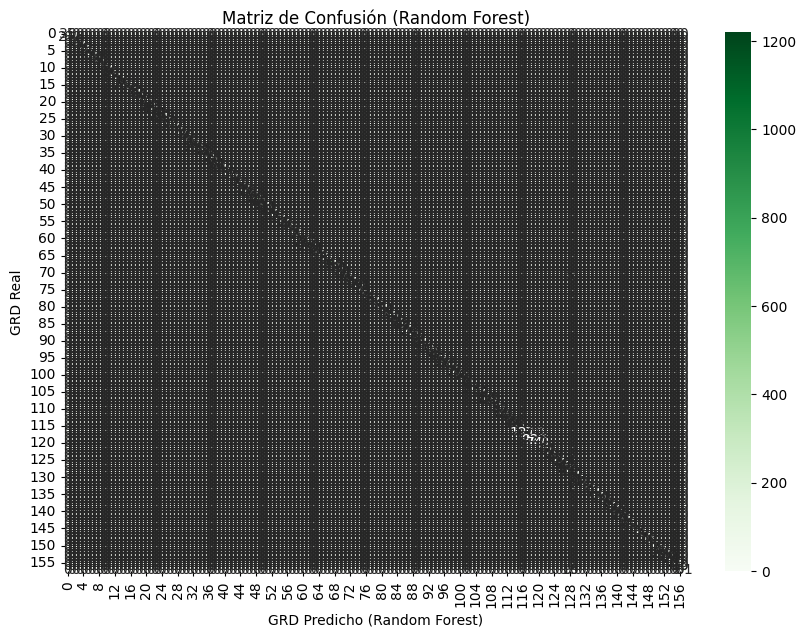

In [6]:

# 2. Crear e entrenar el modelo de Random Forest
# Puedes ajustar los hiperparámetros como 'n_estimators' (número de árboles),
# 'max_depth', 'random_state' para reproducibilidad, etc.
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf.fit(Explicativas_rf, Objetivo_rf)

# 3. (Opcional) Visualizar uno de los árboles del bosque
#plt.figure(figsize=(15,10))
#plot_tree(modelo_rf.estimators_[0], feature_names=Explicativas_rf.columns, class_names=Objetivo_rf.unique().astype(str), filled=True)
#plt.show()

# 4. Realizar una predicción sobre un ejemplo (similar al árbol de decisión)
test_ejemplo_rf = Explicativas_rf.sample()
print("Ejemplo para predecir (Random Forest):")
print(test_ejemplo_rf)
print("\nProbabilidades de predicción (Random Forest):")
print(modelo_rf.predict_proba(test_ejemplo_rf))

# 5. Predecir sobre todo el conjunto de datos
predecir_grd_rf = modelo_rf.predict(Explicativas_rf)
print("\nPredicciones del Random Forest:")
print(predecir_grd_rf)

# 6. Evaluar el modelo: Matriz de confusión
matriz_confusion_rf = confusion_matrix(dataset_el_pino['GRD'], predecir_grd_rf)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf, annot=True, fmt="d", cmap="Greens") # Cambié el mapa de color para diferenciar
plt.xlabel('GRD Predicho (Random Forest)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()



In [7]:
# 7. Calcular el porcentaje de aciertos
porcentaje_rf = np.round(((dataset_el_pino['GRD'] == predecir_grd_rf).sum())/len(dataset_el_pino) * 100, decimals=2) # Usé len() en lugar de 'rows' por seguridad
print(f"\nPorcentaje del modelo Random Forest: {porcentaje_rf}%")


Porcentaje del modelo Random Forest: 99.82%


In [8]:
def medir_modelos(predecir):
    # Calcular accuracy
    accuracy = accuracy_score(dataset_el_pino['GRD'], predecir) * 100
    print(f"Accuracy: {accuracy:.2f}%")
    
    # Calcular precision
    precision = precision_score(dataset_el_pino['GRD'], predecir, average='macro', zero_division=0) * 100
    print(f"Precision (macro): {precision:.2f}%")
    
    # Calcular recall
    recall = recall_score(dataset_el_pino['GRD'], predecir, average='macro', zero_division=0) * 100
    print(f"Recall (macro): {recall:.2f}%")

In [9]:
# 8. Utilizar la función para medir el modelo
print("Métricas del modelo Random Forest:")
medir_modelos(predecir_grd_rf)

Métricas del modelo Random Forest:
Accuracy: 99.82%
Precision (macro): 99.96%
Recall (macro): 99.78%


## Modelo 2

In [12]:
Explicativas_rf2 = dataset_el_pino.drop(columns=delete_rows[1])
Objetivo_rf2 = dataset_el_pino.GRD

In [13]:
modelo_rf2 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf2.fit(Explicativas_rf2, Objetivo_rf2)

# 3. (Opcional) Visualizar uno de los árboles del bosque
#plt.figure(figsize=(15,10))
#plot_tree(modelo_rf2.estimators_[0], feature_names=Explicativas_rf2.columns, class_names=Objetivo_rf2.unique().astype(str), filled=True)
#plt.show()


RandomForestClassifier(max_depth=20, random_state=42)

Ejemplo para predecir (Random Forest):
       Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
10419                          841                           905   

       Diag 03 Secundario (cod+des)  Diag 04 Secundario (cod+des)  \
10419                           875                           756   

       Diag 05 Secundario (cod+des)  Diag 06 Secundario (cod+des)  \
10419                           662                           588   

       Diag 07 Secundario (cod+des)  Diag 08 Secundario (cod+des)  \
10419                           712                           625   

       Diag 09 Secundario (cod+des)  Diag 10 Secundario (cod+des)  ...  \
10419                           543                           491  ...   

       Proced 21 Secundario (cod+des)  Proced 22 Secundario (cod+des)  \
10419                               0                               0   

       Proced 23 Secundario (cod+des)  Proced 24 Secundario (cod+des)  \
10419                               0 

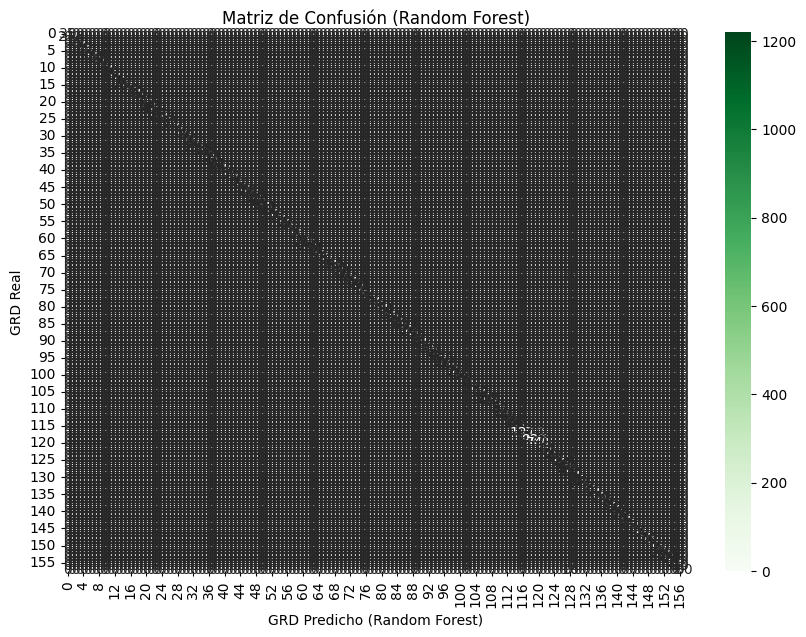

In [14]:

# 4. Realizar una predicción sobre un ejemplo (similar al árbol de decisión)
test_ejemplo_rf2 = Explicativas_rf2.sample()
print("Ejemplo para predecir (Random Forest):")
print(test_ejemplo_rf2)
print("\nProbabilidades de predicción (Random Forest):")
print(modelo_rf2.predict_proba(test_ejemplo_rf2))

# 5. Predecir sobre todo el conjunto de datos
predecir_grd_rf2 = modelo_rf2.predict(Explicativas_rf2)
print("\nPredicciones del Random Forest:")
print(predecir_grd_rf2)

# 6. Evaluar el modelo: Matriz de confusión
matriz_confusion_rf2 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd_rf2)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf2, annot=True, fmt="d", cmap="Greens") # Cambié el mapa de color para diferenciar
plt.xlabel('GRD Predicho (Random Forest)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()

In [15]:
# 7. Calcular el porcentaje de aciertos
porcentaje_rf = np.round(((dataset_el_pino['GRD'] == predecir_grd_rf).sum())/len(dataset_el_pino) * 100, decimals=2) # Usé len() en lugar de 'rows' por seguridad
print(f"\nPorcentaje del modelo Random Forest: {porcentaje_rf}%")


Porcentaje del modelo Random Forest: 99.82%


In [16]:
print("Métricas del modelo Random Forest:")
medir_modelos(predecir_grd_rf)

Métricas del modelo Random Forest:
Accuracy: 99.82%
Precision (macro): 99.96%
Recall (macro): 99.78%


## Modelo 3

# 70 30

## Modelo 1

## Modelo 2